# Air Quality UCI Complete Notebook

#Introduction
Air pollution is one of the major environmental issues in the modern world. Different harmful gases and atmospheric conditions affect human health and environmental quality. In this project, we analyze atmospheric and air quality data using data science and visualization techniques.

The main objective of this analysis is to classify different air quality conditions, identify pollution levels, and understand the relationship between environmental parameters such as temperature, humidity, and harmful gases.

In this simulation lab project, different sensor values and pollutant concentrations are analyzed to determine whether the air quality is good, moderate, or harmful. Various graphs and visualizations are used to better understand the dataset and observe pollution trends.

This project helps us understand:

- Air quality monitoring
- Pollution classification
- Environmental data analysis
- Good vs bad air condition identification
- Relationship between atmospheric variables

Using data visualization and classification techniques, we can easily interpret environmental conditions and make better observations about air pollution levels.

In [ ]:
!pip -q install xgboost tensorflow missingno


## 1. Import libraries


In [ ]:
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.preprocessing import StandardScaler, MinMaxScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, auc
)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, IsolationForest
from sklearn.svm import SVC, OneClassSVM
from sklearn.linear_model import LogisticRegression
from xgboost import XGBRegressor, XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 2. Upload or define file path


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Atmos_Research/AirQualityUCI.csv', header=0)

## 3. Load dataset


In [ ]:
FILE_PATH = '/content/drive/MyDrive/Atmos_Research/AirQualityUCI.csv'
df = pd.read_csv(FILE_PATH, sep=';', decimal=',')
print("Original shape:", df.shape)
display(df.head())

Original shape: (9471, 17)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


## 4. Keep only required columns


In [ ]:
df = df.dropna(axis=1, how='all')
df = df.loc[:, ~df.columns.str.contains('^Unnamed', case=False, regex=True)]

if 'T' in df.columns and 'Temperature' not in df.columns:
    df = df.rename(columns={'T': 'Temperature'})

required_columns = [
    'Date', 'Time',
    'CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)',
    'PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
    'Temperature', 'RH', 'AH'
]

missing_required = [c for c in required_columns if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df = df[required_columns].copy()
print("Shape after selecting required columns:", df.shape)
display(df.head())


Shape after selecting required columns: (9471, 15)


,Date,Time,CO(GT),NMHC(GT),C6H6(GT),NOx(GT),NO2(GT),PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),Temperature,RH,AH
0,10/03/2004,18.00.00,2.6,150.0,11.9,166.0,113.0,1360.0,1046.0,1056.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,112.0,9.4,103.0,92.0,1292.0,955.0,1174.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,88.0,9.0,131.0,114.0,1402.0,939.0,1140.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,80.0,9.2,172.0,122.0,1376.0,948.0,1092.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,51.0,6.5,131.0,116.0,1272.0,836.0,1205.0,1490.0,1110.0,11.2,59.6,0.7888


## 5. Replace -200 with NaN


In [ ]:
numeric_cols = [c for c in df.columns if c not in ['Date', 'Time']]
df[numeric_cols] = df[numeric_cols].replace(-200, np.nan)


## 6. Missing value map before cleaning


<Figure size 1200x500 with 0 Axes>

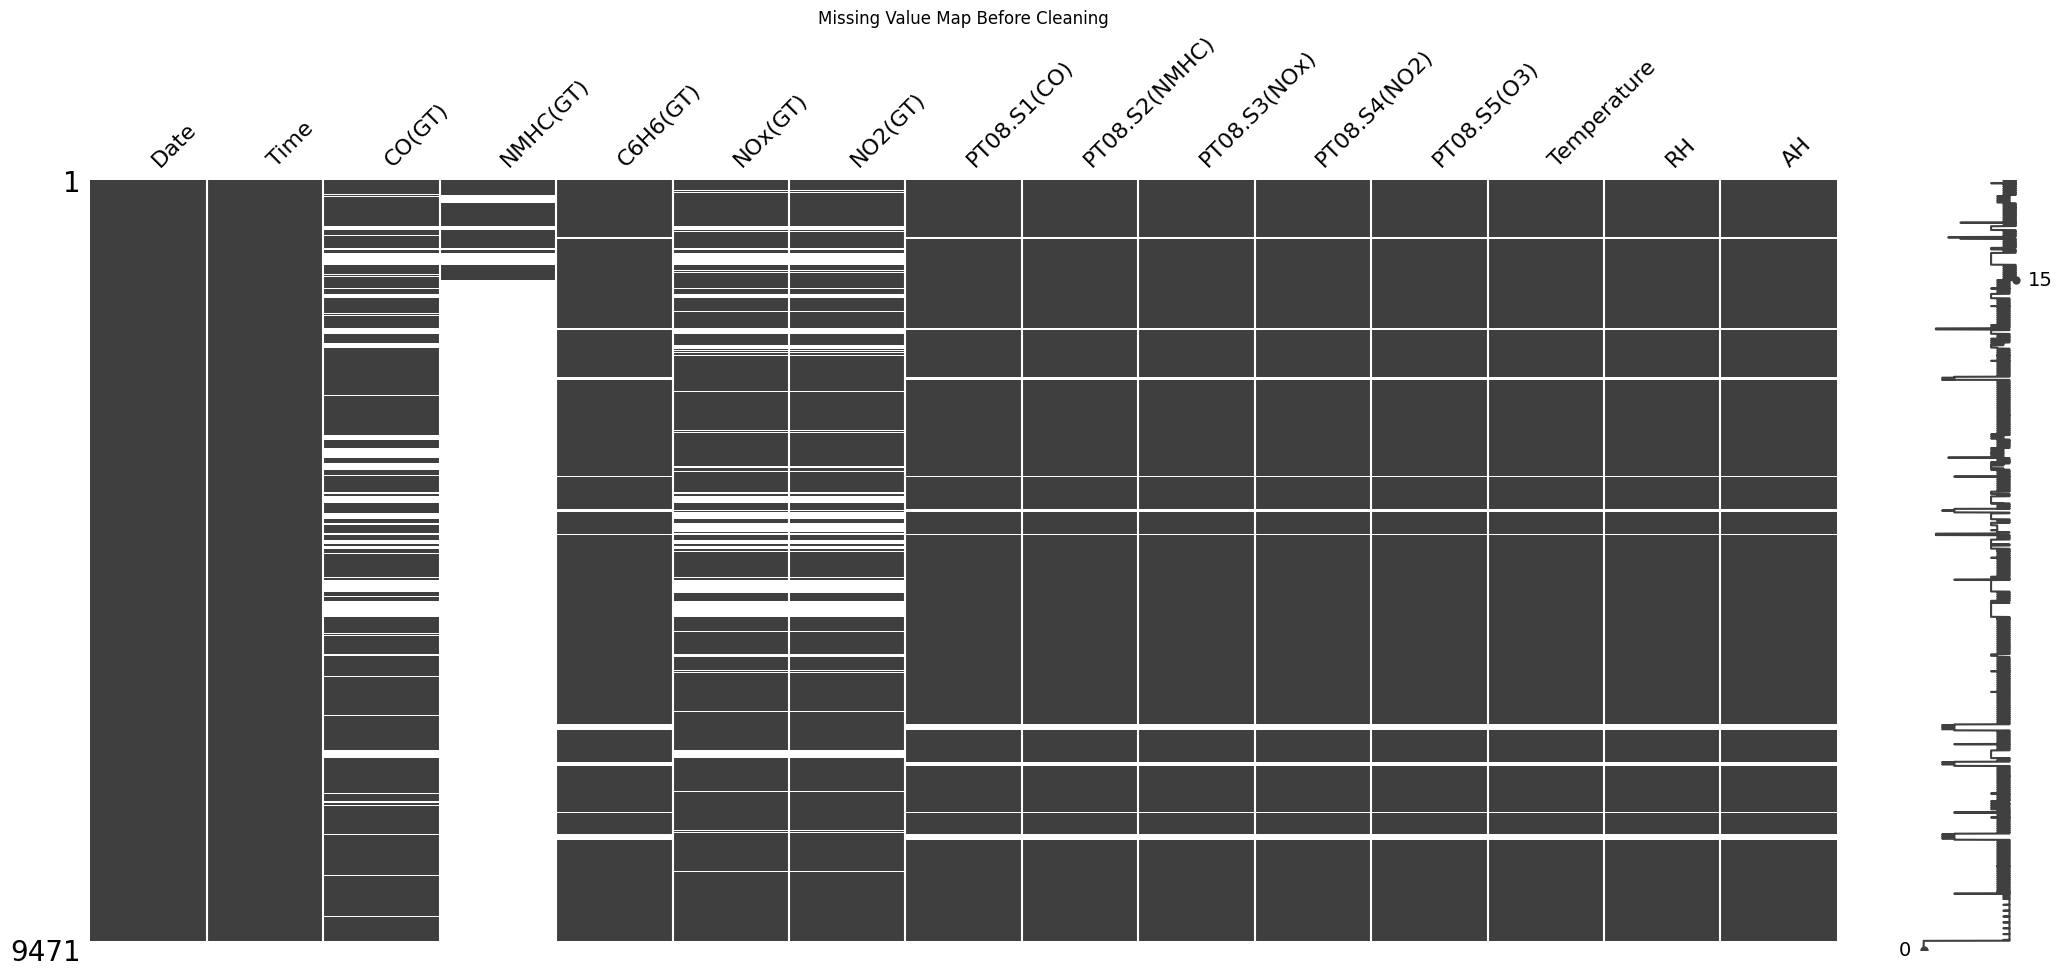

In [ ]:
plt.figure(figsize=(12, 5))
msno.matrix(df)
plt.title("Missing Value Map Before Cleaning")
plt.show()


## 7. Merge date and time into datetime


In [ ]:
df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H.%M.%S',
    errors='coerce'
)

df = df.dropna(subset=['datetime']).copy()
df = df.sort_values('datetime').reset_index(drop=True)
df = df.drop_duplicates(subset=['datetime']).reset_index(drop=True)
df = df.set_index('datetime')

print("Shape after datetime conversion:", df.shape)
display(df.head())


Shape after datetime conversion: (9357, 15)


,Date,Time,CO(GT),NMHC(GT),C6H6(GT),NOx(GT),NO2(GT),PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),Temperature,RH,AH
datetime,,,,,,,,,,,,,,,
2004-03-10 18:00:00,10/03/2004,18.00.00,2.6,150.0,11.9,166.0,113.0,1360.0,1046.0,1056.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,10/03/2004,19.00.00,2.0,112.0,9.4,103.0,92.0,1292.0,955.0,1174.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,10/03/2004,20.00.00,2.2,88.0,9.0,131.0,114.0,1402.0,939.0,1140.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,10/03/2004,21.00.00,2.2,80.0,9.2,172.0,122.0,1376.0,948.0,1092.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,10/03/2004,22.00.00,1.6,51.0,6.5,131.0,116.0,1272.0,836.0,1205.0,1490.0,1110.0,11.2,59.6,0.7888


## 8. Interpolate and impute missing values


In [ ]:
df[numeric_cols] = df[numeric_cols].interpolate(method='time')

median_imputer = SimpleImputer(strategy='median')
df[numeric_cols] = median_imputer.fit_transform(df[numeric_cols])

print("Remaining missing values:")
print(df.isna().sum().sort_values(ascending=False).head(10))


Remaining missing values:
Date             0
Time             0
CO(GT)           0
NMHC(GT)         0
C6H6(GT)         0
NOx(GT)          0
NO2(GT)          0
PT08.S1(CO)      0
PT08.S2(NMHC)    0
PT08.S3(NOx)     0
dtype: int64


## 9. Remove invalid values


In [ ]:
target_col = 'C6H6(GT)'
pollutant_cols = ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

for col in pollutant_cols:
    df = df[(df[col].isna()) | (df[col] >= 0)]

df = df.dropna(subset=[target_col]).copy()

df['Date'] = df.index.date.astype(str)
df['Time'] = df.index.time.astype(str)

print("Shape after preprocessing:", df.shape)
display(df.head())


Shape after preprocessing: (9357, 15)


,Date,Time,CO(GT),NMHC(GT),C6H6(GT),NOx(GT),NO2(GT),PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),Temperature,RH,AH
datetime,,,,,,,,,,,,,,,
2004-03-10 18:00:00,2004-03-10,18:00:00,2.6,150.0,11.9,166.0,113.0,1360.0,1046.0,1056.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2004-03-10,19:00:00,2.0,112.0,9.4,103.0,92.0,1292.0,955.0,1174.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2004-03-10,20:00:00,2.2,88.0,9.0,131.0,114.0,1402.0,939.0,1140.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2004-03-10,21:00:00,2.2,80.0,9.2,172.0,122.0,1376.0,948.0,1092.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,2004-03-10,22:00:00,1.6,51.0,6.5,131.0,116.0,1272.0,836.0,1205.0,1490.0,1110.0,11.2,59.6,0.7888


## 10. Target distribution


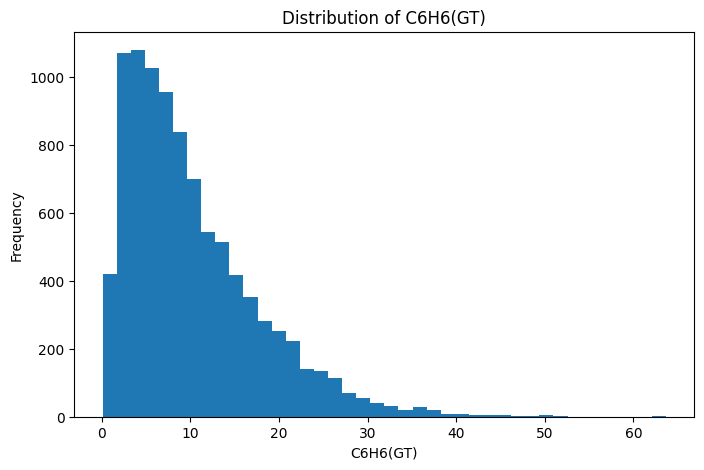

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df[target_col], bins=40)
plt.title("Distribution of C6H6(GT)")
plt.xlabel("C6H6(GT)")
plt.ylabel("Frequency")
plt.show()


## 11. Sensor histograms


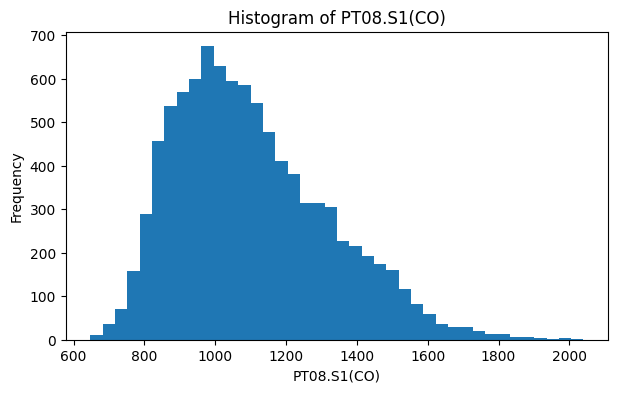

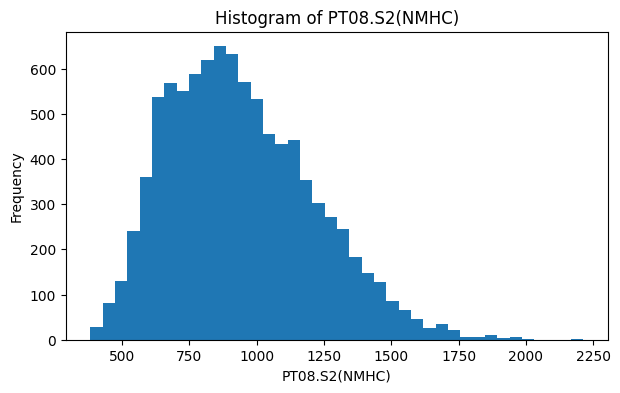

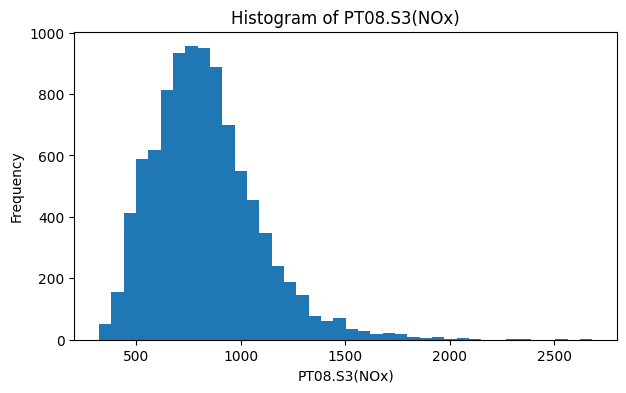

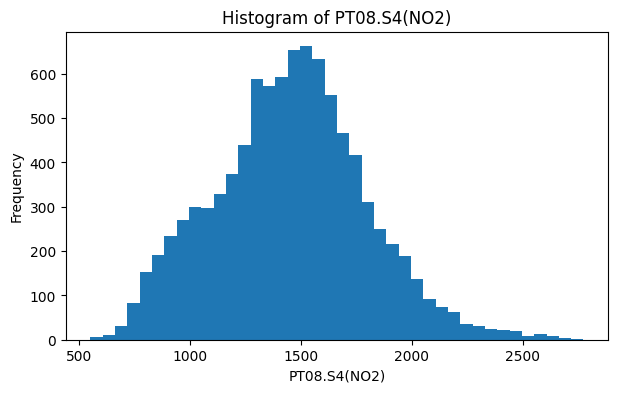

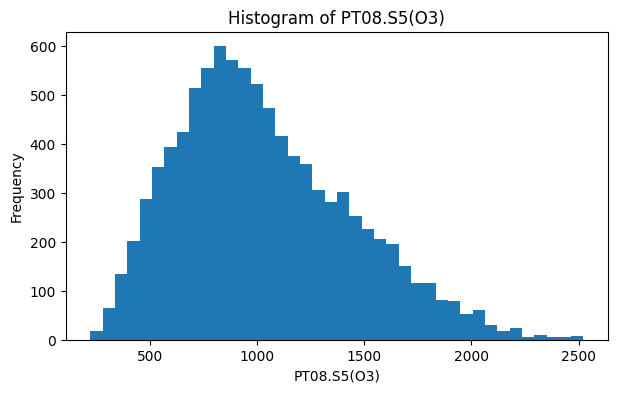

In [ ]:
sensor_cols = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)']

for col in sensor_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col], bins=40)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()
    print()


## 12. Correlation heatmap


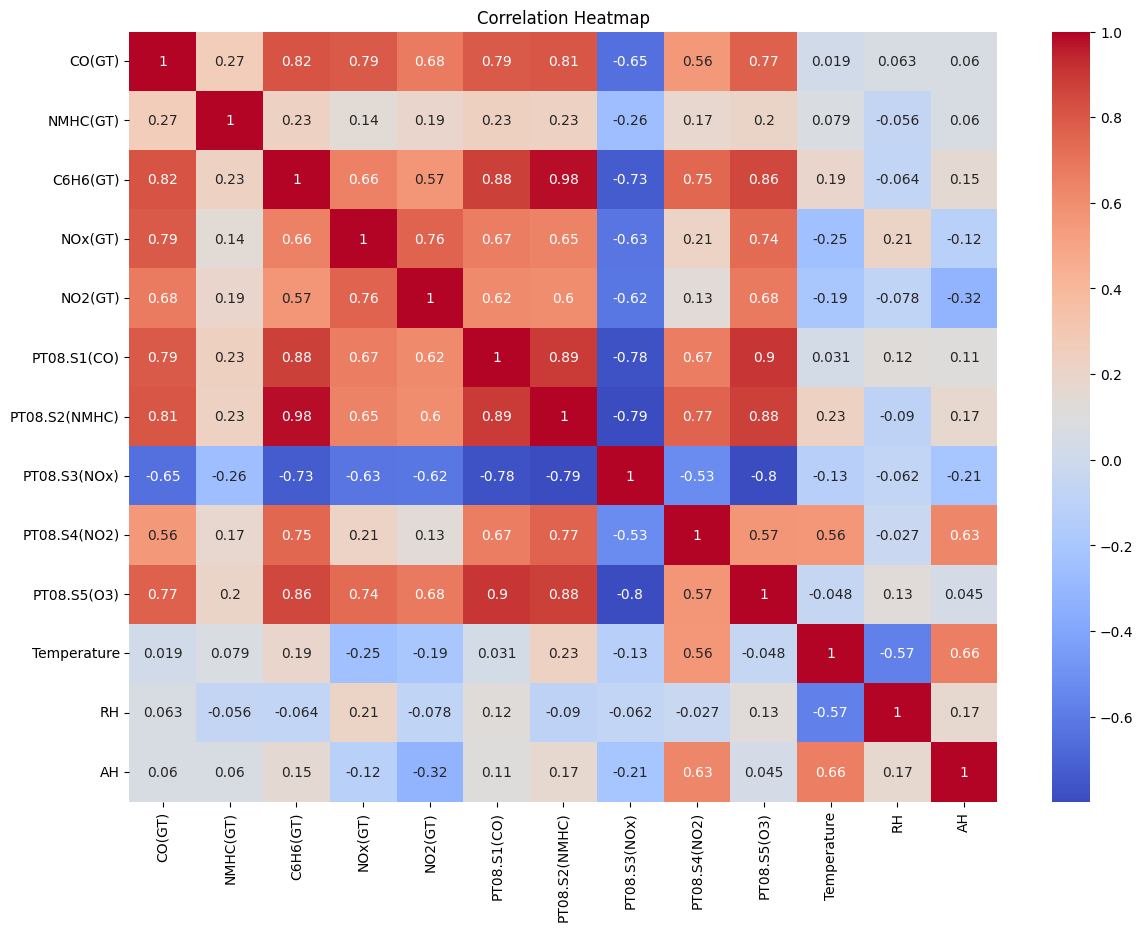

In [ ]:
corr_cols = pollutant_cols + sensor_cols + ['Temperature', 'RH', 'AH']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


## 13. Hourly trend


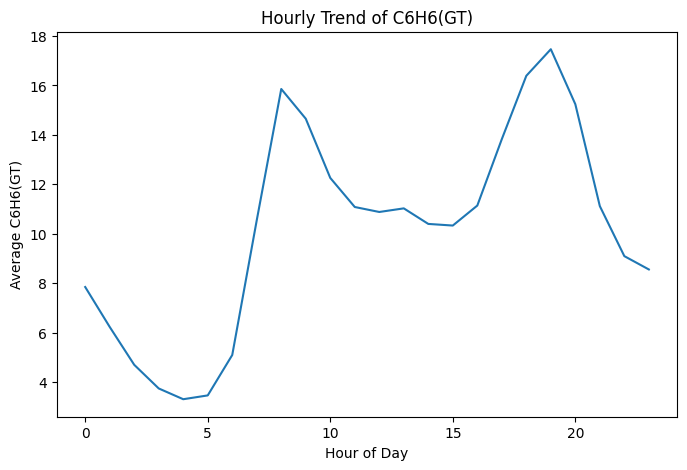

In [ ]:
df['hour'] = df.index.hour
hourly_mean = df.groupby('hour')[target_col].mean()

plt.figure(figsize=(8, 5))
plt.plot(hourly_mean.index, hourly_mean.values)
plt.title("Hourly Trend of C6H6(GT)")
plt.xlabel("Hour of Day")
plt.ylabel("Average C6H6(GT)")
plt.show()


## 14. Monthly trend


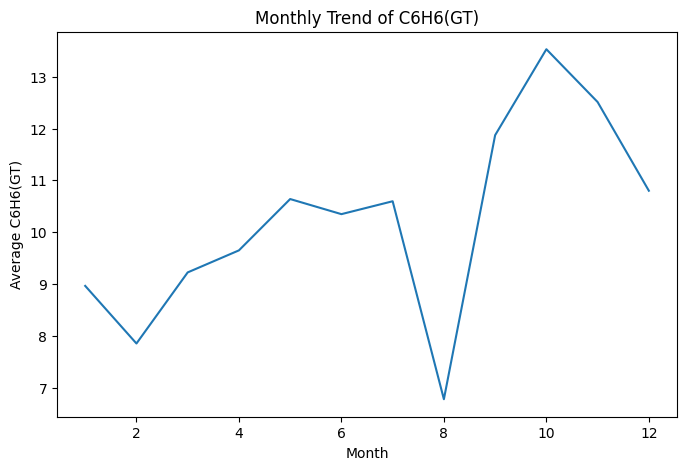

In [ ]:
df['month'] = df.index.month
monthly_mean = df.groupby('month')[target_col].mean()

plt.figure(figsize=(8, 5))
plt.plot(monthly_mean.index, monthly_mean.values)
plt.title("Monthly Trend of C6H6(GT)")
plt.xlabel("Month")
plt.ylabel("Average C6H6(GT)")
plt.show()


## 15. Temporal features


In [ ]:
df['day'] = df.index.day
df['day_of_week'] = df.index.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

display(df[['hour', 'day', 'month', 'day_of_week', 'is_weekend']].head())


,hour,day,month,day_of_week,is_weekend
datetime,,,,,
2004-03-10 18:00:00,18,10,3,2,0
2004-03-10 19:00:00,19,10,3,2,0
2004-03-10 20:00:00,20,10,3,2,0
2004-03-10 21:00:00,21,10,3,2,0
2004-03-10 22:00:00,22,10,3,2,0


## 16. Lag features


In [ ]:
for lag in [1, 3, 6, 24]:
    df[f'{target_col}_lag_{lag}'] = df[target_col].shift(lag)

for sensor in ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)']:
    for lag in [1, 6]:
        df[f'{sensor}_lag_{lag}'] = df[sensor].shift(lag)

print("Lag features created.")


Lag features created.


## 17. Rolling statistics


In [ ]:
rolling_base_cols = [target_col, 'PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)']

for col in rolling_base_cols:
    for window in [3, 6, 24]:
        df[f'{col}_roll_mean_{window}'] = df[col].rolling(window).mean()
        df[f'{col}_roll_std_{window}'] = df[col].rolling(window).std()
        df[f'{col}_roll_max_{window}'] = df[col].rolling(window).max()
        df[f'{col}_roll_min_{window}'] = df[col].rolling(window).min()

print("Rolling features created.")


Rolling features created.


## 18. Interaction features


In [ ]:
df['Temperature_x_RH'] = df['Temperature'] * df['RH']
df['AH_x_Temperature'] = df['AH'] * df['Temperature']
df['PT08.S1_x_Temperature'] = df['PT08.S1(CO)'] * df['Temperature']
df['PT08.S2_x_RH'] = df['PT08.S2(NMHC)'] * df['RH']
df['PT08.S3_x_AH'] = df['PT08.S3(NOx)'] * df['AH']

print("Interaction features created.")


Interaction features created.


## 19. Create regression, classification, and anomaly targets


In [ ]:
df['target_t1'] = df[target_col].shift(-1)
df['target_t6'] = df[target_col].shift(-6)
df['target_t24'] = df[target_col].shift(-24)

df['severity_class'] = pd.qcut(
    df[target_col],
    q=4,
    labels=[0, 1, 2, 3]
).astype('float')

rolling_mean = df[target_col].rolling(24).mean()
rolling_std = df[target_col].rolling(24).std()
df['anomaly_label'] = ((df[target_col] > (rolling_mean + 3 * rolling_std))).astype(int)

df_model = df.dropna().copy()
print("Final modeling shape:", df_model.shape)
display(df_model.head())


Final modeling shape: (9309, 88)


,Date,Time,CO(GT),NMHC(GT),C6H6(GT),NOx(GT),NO2(GT),PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),...,Temperature_x_RH,AH_x_Temperature,PT08.S1_x_Temperature,PT08.S2_x_RH,PT08.S3_x_AH,target_t1,target_t6,target_t24,severity_class,anomaly_label
datetime,,,,,,,,,,,,,,,,,,,,,
2004-03-11 18:00:00,2004-03-11,18:00:00,4.8,307.0,20.8,281.0,151.0,1581.0,1319.0,799.0,...,661.26,8.30695,16284.3,84679.8,644.3935,27.4,5.9,19.3,3.0,1
2004-03-11 19:00:00,2004-03-11,19:00:00,6.9,461.0,27.4,383.0,172.0,1776.0,1488.0,702.0,...,672.21,8.06943,17227.2,103118.4,583.9938,24.0,6.4,18.2,3.0,1
2004-03-11 20:00:00,2004-03-11,20:00:00,6.1,401.0,24.0,351.0,165.0,1640.0,1404.0,743.0,...,650.88,7.80768,15744.0,95191.2,604.2819,12.8,4.1,32.6,3.0,0
2004-03-11 21:00:00,2004-03-11,21:00:00,3.9,197.0,12.8,240.0,136.0,1313.0,1076.0,957.0,...,582.40,6.75129,11948.3,68864.0,709.9983,4.7,1.9,20.1,2.0,0
2004-03-11 22:00:00,2004-03-11,22:00:00,1.5,61.0,4.7,94.0,85.0,965.0,749.0,1325.0,...,519.88,5.66210,7913.0,47486.6,914.9125,2.6,1.1,14.3,1.0,0


## 20. Define feature sets


In [ ]:
base_features = [
    'PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)'
]

env_features = ['Temperature', 'RH', 'AH']
temporal_features = ['hour', 'day', 'month', 'day_of_week', 'is_weekend']
lag_features = [c for c in df_model.columns if '_lag_' in c]
rolling_features = [c for c in df_model.columns if '_roll_' in c]

interaction_features = [
    'Temperature_x_RH', 'AH_x_Temperature', 'PT08.S1_x_Temperature',
    'PT08.S2_x_RH', 'PT08.S3_x_AH'
]

all_features = base_features + env_features + temporal_features + lag_features + rolling_features + interaction_features

print("Total features:", len(all_features))


Total features: 76


## 21. Helper functions


In [ ]:
def time_split(dataframe, feature_cols, target_name):
    X = dataframe[feature_cols].copy()
    y = dataframe[target_name].copy()

    n = len(dataframe)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    X_train = X.iloc[:train_end]
    X_val = X.iloc[train_end:val_end]
    X_test = X.iloc[val_end:]

    y_train = y.iloc[:train_end]
    y_val = y.iloc[train_end:val_end]
    y_test = y.iloc[val_end:]

    return X_train, X_val, X_test, y_train, y_val, y_test

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100
    return rmse, mae, r2, mape

def plot_actual_vs_pred(y_true, y_pred, title):
    plt.figure(figsize=(12, 5))
    plt.plot(y_true.values[:300], label='Actual')
    plt.plot(y_pred[:300], label='Predicted')
    plt.title(title)
    plt.xlabel("Samples")
    plt.ylabel("Target")
    plt.legend()
    plt.show()

def create_sequences(features_array, target_array, seq_len=24):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(features_array)):
        X_seq.append(features_array[i-seq_len:i])
        y_seq.append(target_array[i])
    return np.array(X_seq), np.array(y_seq)

def build_lstm(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=False, input_shape=input_shape),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_gru(input_shape):
    model = Sequential([
        GRU(64, return_sequences=False, input_shape=input_shape),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model


## 22. Regression with Random Forest and XGBoost



REGRESSION FOR target_t1
RandomForest -> RMSE: 2.7817, MAE: 1.8731, R2: 0.7847, MAPE: 33.78%


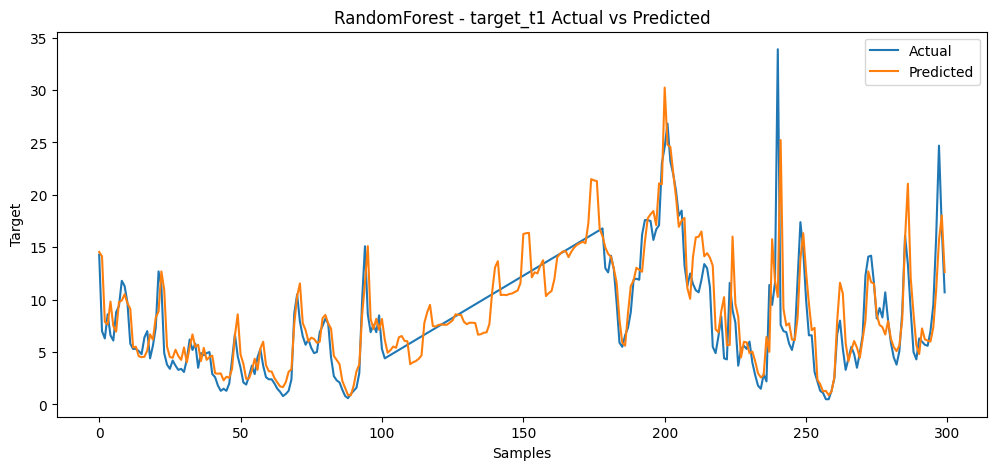

XGBoost -> RMSE: 3.1064, MAE: 2.1405, R2: 0.7315, MAPE: 42.48%


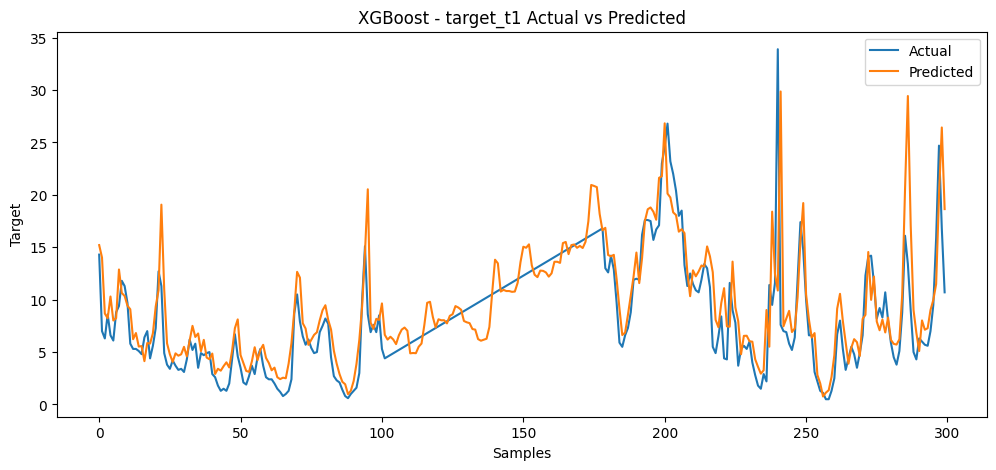


REGRESSION FOR target_t6
RandomForest -> RMSE: 6.7021, MAE: 4.9103, R2: -0.2504, MAPE: 128.22%


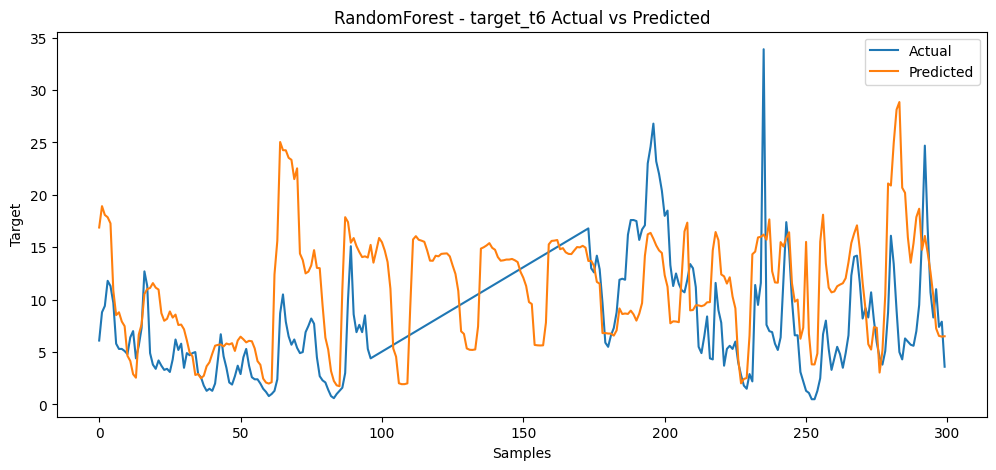

XGBoost -> RMSE: 5.6925, MAE: 4.3573, R2: 0.0979, MAPE: 121.71%


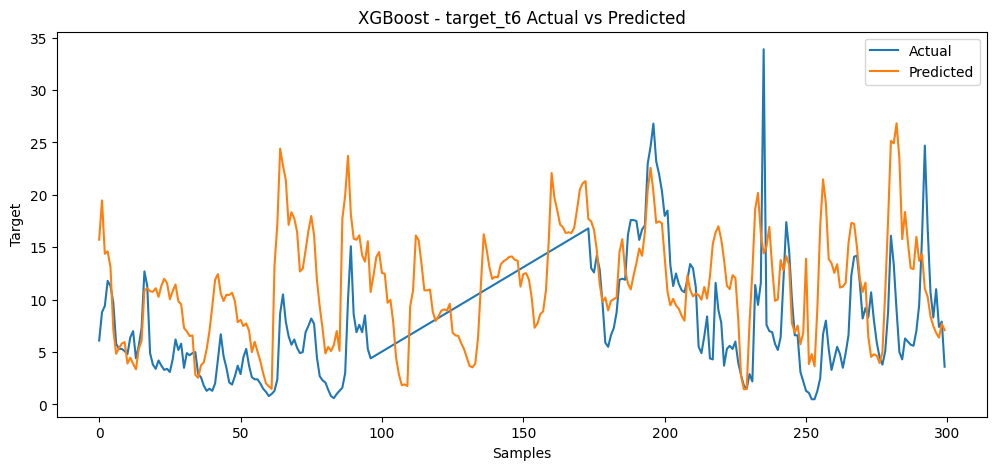


REGRESSION FOR target_t24
RandomForest -> RMSE: 6.0728, MAE: 4.6354, R2: -0.0154, MAPE: 130.77%


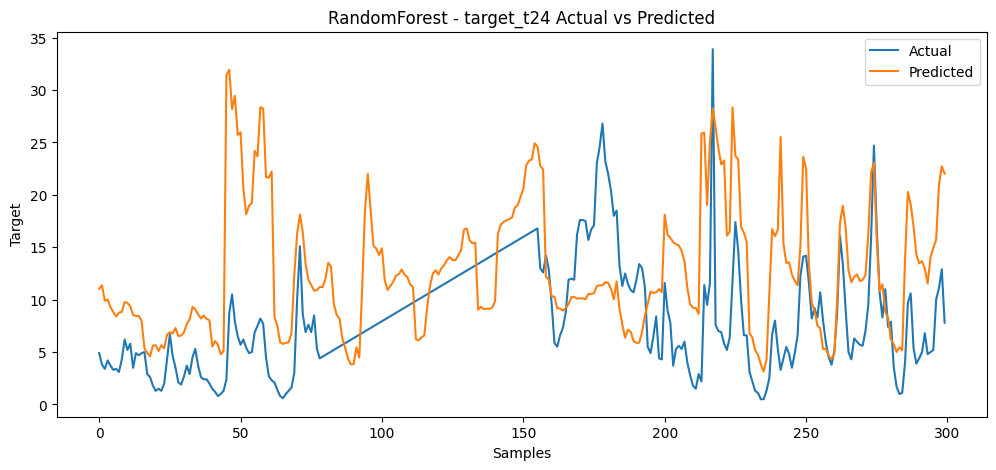

XGBoost -> RMSE: 6.0431, MAE: 4.8055, R2: -0.0055, MAPE: 134.71%


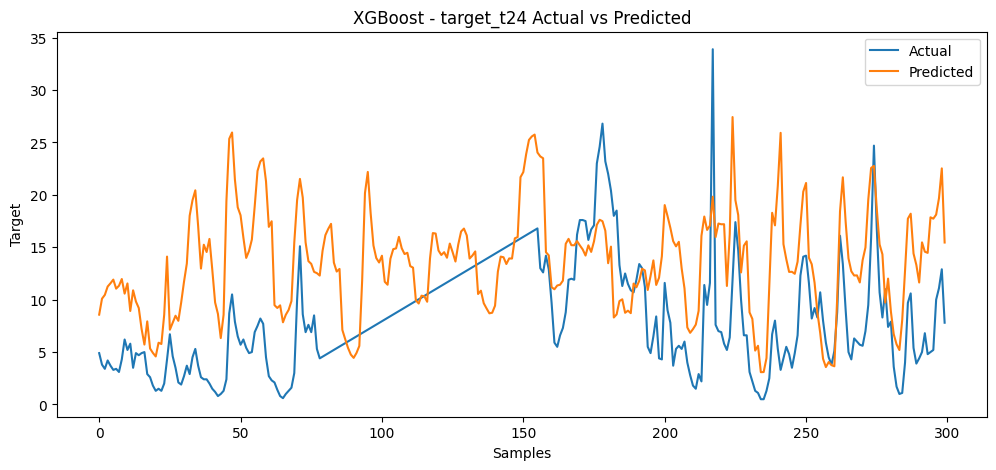

,Horizon,Model,RMSE,MAE,R2,MAPE
0,target_t1,RandomForest,2.781727,1.873077,0.784671,33.778095
1,target_t1,XGBoost,3.106356,2.140476,0.731480,42.481401
2,target_t6,RandomForest,6.702060,4.910271,-0.250443,128.219597
3,target_t6,XGBoost,5.692503,4.357290,0.097902,121.712769
4,target_t24,RandomForest,6.072757,4.635411,-0.015449,130.768018
5,target_t24,XGBoost,6.043060,4.805455,-0.005542,134.712462


In [ ]:
regression_targets = ['target_t1', 'target_t6', 'target_t24']
regression_results = []

for reg_target in regression_targets:
    print(f"\n========================")
    print(f"REGRESSION FOR {reg_target}")
    print(f"========================")

    X_train, X_val, X_test, y_train, y_val, y_test = time_split(df_model, all_features, reg_target)

    std_scaler = StandardScaler()
    X_train_s = std_scaler.fit_transform(X_train)
    X_test_s = std_scaler.transform(X_test)

    models = {
        'RandomForest': RandomForestRegressor(
            n_estimators=200, max_depth=12, random_state=SEED, n_jobs=-1
        ),
        'XGBoost': XGBRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            objective='reg:squarederror', random_state=SEED
        )
    }

    for name, model in models.items():
        model.fit(X_train_s, y_train)
        preds = model.predict(X_test_s)

        rmse, mae, r2, mape = regression_metrics(y_test, preds)
        regression_results.append([reg_target, name, rmse, mae, r2, mape])

        print(f"{name} -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}, MAPE: {mape:.2f}%")
        plot_actual_vs_pred(y_test, preds, f"{name} - {reg_target} Actual vs Predicted")

reg_results_df = pd.DataFrame(
    regression_results,
    columns=['Horizon', 'Model', 'RMSE', 'MAE', 'R2', 'MAPE']
)
display(reg_results_df)


#Pollutant Classification Count

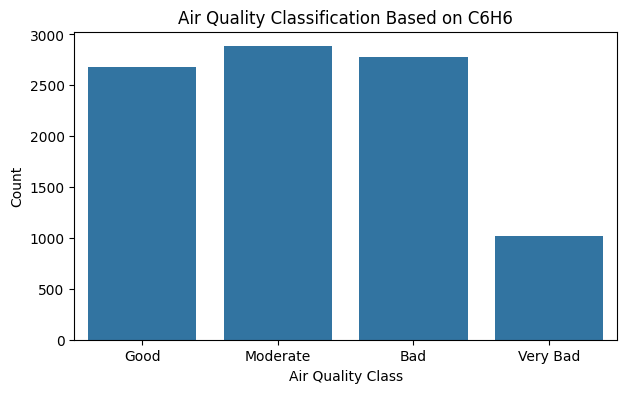

In [ ]:
def classify_c6h6(value):
    if value <= 5:
        return "Good"
    elif value <= 10:
        return "Moderate"
    elif value <= 20:
        return "Bad"
    else:
        return "Very Bad"

df['Air_Quality_Class'] = df['C6H6(GT)'].apply(classify_c6h6)

plt.figure(figsize=(7,4))
sns.countplot(x='Air_Quality_Class', data=df, order=["Good", "Moderate", "Bad", "Very Bad"])
plt.title("Air Quality Classification Based on C6H6")
plt.xlabel("Air Quality Class")
plt.ylabel("Count")
plt.show()

#Correlation Heatmap

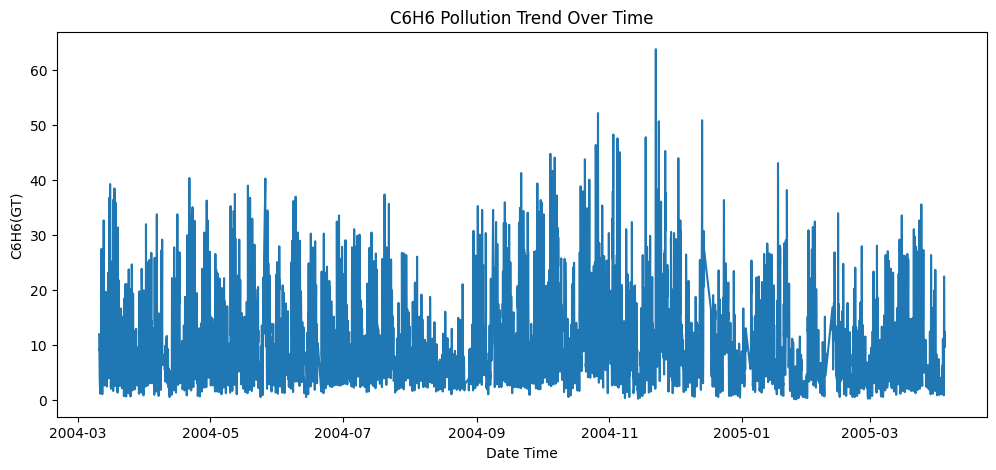

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['C6H6(GT)'])
plt.title("C6H6 Pollution Trend Over Time")
plt.xlabel("Date Time")
plt.ylabel("C6H6(GT)")
plt.show()

In [ ]:
print(df['Air_Quality_Class'].value_counts())

Air_Quality_Class
Moderate    2883
Bad         2774
Good        2679
Very Bad    1021
Name: count, dtype: int64
